# **ICSD dataset**

The selected ICSD Strong data contain two target sound-event classes:

- **Infant Cry:** recordings containing infant crying sounds.
- **Snoring:** recordings containing snoring sounds.


## Environment Setup

In [ ]:
!pip install -q datasets huggingface_hub soundfile librosa pandas matplotlib

In [ ]:
from huggingface_hub import login
login()

## Download & Extract

ICSD was developed for
infant cry and snoring detection and contains three main annotation subsets:
**Weak**, **Real Strong**, and **Synthetic Strong**.

Because these subsets were constructed from different sources, they are kept
separate during the initial analysis. Their source provenance is reviewed
before deciding which subsets can be safely combined with the other datasets
used in Mahd.


In [ ]:
from huggingface_hub import hf_hub_download
import os
import zipfile
import pandas as pd

icsd_dir = "/content/datasets/ICSD"
os.makedirs(icsd_dir, exist_ok=True)

zip_path = hf_hub_download(
    repo_id="QingyuLiu1/ICSD",
    filename="Dataset.zip",
    repo_type="dataset"
)

extract_dir = os.path.join(icsd_dir, "Dataset")

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_dir)

## Load Strong Metadata



ICSD contains weakly labeled data as well as real and synthetic strongly
labeled subsets. The weakly labeled subset was not used in this project
because it was assembled from existing datasets, including Donate-a-Cry,
AudioSet, and ESC-50.

Since Donate-a-Cry is already included separately in Mahd for cry-cause
classification, using the ICSD weak subset could introduce overlapping source
recordings and duplicate data across datasets. To avoid this source overlap,
the weak subset was excluded.

Therefore, only the **Real Strong** and **Synthetic Strong** ICSD subsets are
loaded for the current analysis. These subsets provide strongly annotated
Infant Cry and Snoring events and can be analyzed separately while preserving
their real or synthetic origin.

In [ ]:
metadata_paths = {
    "Real Train": "metadata/train/real_strong_train.tsv",
    "Synthetic Train": "metadata/train/synth_strong_train.tsv",
    "Validation": "metadata/validation/strong_val.tsv",
    "Real Test": "metadata/test/real_strong_test.tsv",
    "Synthetic Test": "metadata/test/synth_strong_test.tsv"
}

metadata = {
    name: pd.read_csv(os.path.join(extract_dir, path), sep="\t")
    for name, path in metadata_paths.items()
}

## Separate Validation

In [ ]:
val_df = metadata["Validation"]

real_val = val_df[
    val_df["filename"].str.startswith("strong_")
].copy()

synth_val = val_df[
    val_df["filename"].str.startswith("synth_")
].copy()

## ICSD Class Distribution

In [ ]:
subsets = {
    "Real Train": metadata["Real Train"],
    "Real Validation": real_val,
    "Real Test": metadata["Real Test"],
    "Synthetic Train": metadata["Synthetic Train"],
    "Synthetic Validation": synth_val,
    "Synthetic Test": metadata["Synthetic Test"]
}

rows = []

for name, df in subsets.items():
    unique_files = df[["filename", "event_label"]].drop_duplicates()
    counts = unique_files["event_label"].value_counts()

    rows.append({
        "Subset": name,
        "Infant Cry": counts.get("Infantcry", 0),
        "Snoring": counts.get("Snoring", 0),
        "Total": len(unique_files)
    })

icsd_distribution = pd.DataFrame(rows)

icsd_distribution["Infant Cry %"] = (
    icsd_distribution["Infant Cry"] /
    icsd_distribution["Total"] * 100
).round(2)

icsd_distribution["Snoring %"] = (
    icsd_distribution["Snoring"] /
    icsd_distribution["Total"] * 100
).round(2)

display(icsd_distribution)

,Subset,Infant Cry,Snoring,Total,Infant Cry %,Snoring %
0,Real Train,338,305,643,52.57,47.43
1,Real Validation,43,39,82,52.44,47.56
2,Real Test,43,39,82,52.44,47.56
3,Synthetic Train,4000,4000,8000,50.00,50.00
4,Synthetic Validation,500,500,1000,50.00,50.00
5,Synthetic Test,500,500,1000,50.00,50.00


## ICSD Materials

The ICSD Materials are organized into foreground and background sounds used
to construct the Synthetic Strong recordings [1]:

- **Foreground:** Infant Cry and Snoring, which represent the target sound
  events.
- **Background:** non-target sounds from different environments and activities,
  such as speech, music, cooking, vacuum cleaning, and watching TV.

The Materials are not treated as additional ICSD classes because they are
source sounds used to construct the synthetic recordings. The background
materials are examined separately as potential Non-Cry data for Mahd.

In [ ]:
from huggingface_hub import hf_hub_download
import os
import zipfile

materials_zip = hf_hub_download(
    repo_id="QingyuLiu1/ICSD",
    filename="Materials.zip",
    repo_type="dataset"
)

materials_dir = "/content/datasets/ICSD/Materials"

os.makedirs(materials_dir, exist_ok=True)

with zipfile.ZipFile(materials_zip, "r") as zip_ref:
    zip_ref.extractall(materials_dir)

print("Extracted to:", materials_dir)

Extracted to: /content/datasets/ICSD/Materials


# **Donate a cry dataset**

The selected Donate-a-Cry recordings are organized into five original
cry-reason labels:

- **Hungry:** crying associated with suspected hunger.
- **Discomfort:** crying associated with suspected discomfort.
- **Tired:** crying associated with suspected tiredness.
- **Belly Pain:** crying associated with suspected belly pain.
- **Burping:** crying associated with the need to burp.

These labels represent the suspected reason associated with each contributed
cry recording rather than clinically confirmed diagnoses.

## Download

In [ ]:
!git clone -q https://github.com/gveres/donateacry-corpus.git /content/datasets/donateacry-corpus

donate_dir = "/content/datasets/donateacry-corpus"

fatal: destination path '/content/datasets/donateacry-corpus' already exists and is not an empty directory.


## Find Audio Files

Donate-a-Cry provides infant cry recordings labeled according to the
**suspected reason for crying** reported with each contribution, including
hungry, discomfort, tired, belly pain, and burping. For this analysis,
we use the `donateacry_corpus_cleaned_and_updated_data` directory, which
contains the cleaned and updated version of the corpus. Restricting the
analysis to this directory prevents files from other repository folders from
being counted together with the selected version. This results in a total of
457 audio recordings used for the subsequent class-distribution analysis.

In [ ]:
import os
import pandas as pd

donate_clean_dir = os.path.join(
    donate_dir,
    "donateacry_corpus_cleaned_and_updated_data"
)

donate_files = []

for root, dirs, files in os.walk(donate_clean_dir):
    for file in files:
        if file.lower().endswith((".wav", ".caf", ".3gp", ".mp3", ".m4a", ".ogg")):
            donate_files.append(os.path.join(root, file))

print("Total audio files:", len(donate_files))
print("Total audio files:", len(donate_files))

Total audio files: 457
Total audio files: 457


## Discover Labels

In [ ]:
records = []

for path in donate_files:
    label = os.path.basename(os.path.dirname(path))

    records.append({
        "filename": os.path.basename(path),
        "audio_path": path,
        "original_label": label
    })

donate_df = pd.DataFrame(records)

print("Discovered classes:")
print(sorted(donate_df["original_label"].unique()))

Discovered classes:
['belly_pain', 'burping', 'discomfort', 'hungry', 'tired']


## Donate a cry Class Distribution

In [ ]:
donate_distribution = (
    donate_df["original_label"]
    .value_counts()
    .rename_axis("Class")
    .reset_index(name="Count")
)

donate_distribution["Percentage"] = (
    donate_distribution["Count"]
    / donate_distribution["Count"].sum()
    * 100
).round(2)

display(donate_distribution)

print("Total:", len(donate_df))

,Class,Count,Percentage
0,hungry,382,83.59
1,discomfort,27,5.91
2,tired,24,5.25
3,belly_pain,16,3.50
4,burping,8,1.75


Total: 457


# **OSF dataset**

The OSF dataset accompanies a controlled study of acoustic characteristics in
human baby cries. It contains natural cry recordings collected under
discomfort and vaccination-related pain conditions, in addition to synthetic
and playback materials used for other parts of the study.



# Extract

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
osf_root = "/content/drive/MyDrive/Mahd/OSF"
print(os.path.exists(osf_root))
print(os.listdir(osf_root))

True
['Data - acute pain cries', 'Data - discomfort cries', 'Data - residual pain cries']


In [ ]:
import glob
import pandas as pd

audio_exts = ("*.wav", "*.mp3", "*.flac", "*.ogg")
osf_files = []
for ext in audio_exts:
    osf_files += glob.glob(os.path.join(osf_root, "**", ext), recursive=True)

osf_df = pd.DataFrame({"audio_path": osf_files})
osf_df["cry_type"] = osf_df["audio_path"].apply(lambda p: os.path.basename(os.path.dirname(p)))
osf_df["label"] = "Cry"
osf_df["source"] = "OSF"

print("Total OSF cry files found:", len(osf_df))
display(osf_df["cry_type"].value_counts())
display(osf_df.head())

Total OSF cry files found: 304


,count
cry_type,
Data - discomfort cries,210
Data - acute pain cries,48
Data - residual pain cries,46


,audio_path,cry_type,label,source
0,/content/drive/MyDrive/Mahd/OSF/Data - acute p...,Data - acute pain cries,Cry,OSF
1,/content/drive/MyDrive/Mahd/OSF/Data - acute p...,Data - acute pain cries,Cry,OSF
2,/content/drive/MyDrive/Mahd/OSF/Data - acute p...,Data - acute pain cries,Cry,OSF
3,/content/drive/MyDrive/Mahd/OSF/Data - acute p...,Data - acute pain cries,Cry,OSF
4,/content/drive/MyDrive/Mahd/OSF/Data - acute p...,Data - acute pain cries,Cry,OSF


## Discover Natural Cry Classes

For Mahd, only the **Natural Cries** are selected because they represent actual
infant cry recordings collected under documented conditions relevant to
cry-cause classification: **Discomfort, Acute Pain, and Residual Pain**.
The synthetic and playback audio are experimental materials rather than
additional natural infant cry recordings, so they are not included as
independent samples in the Mahd cry-cause dataset.

The selected Natural Cries are organized into three conditions defined by the
study:

- **Discomfort:** cries recorded during bathing, dressing, or undressing.
- **Acute Pain:** cries recorded at the time of vaccine injection.
- **Residual Pain:** cries recorded approximately six seconds after injection.


In [ ]:
import os
import pandas as pd

natural_dir = "/content/drive/MyDrive/Mahd/OSF"   # <-- corrected path, no extra subfolder

records = []

for folder in os.listdir(natural_dir):
    folder_path = os.path.join(natural_dir, folder)

    if folder.startswith("Data -") and os.path.isdir(folder_path):
        for file in os.listdir(folder_path):
            if file.lower().endswith(".wav"):
                records.append({
                    "filename": file,
                    "audio_path": os.path.join(folder_path, file),
                    "original_label": folder
                })

osf_df = pd.DataFrame(records)

print("Discovered classes:")
print(sorted(osf_df["original_label"].unique()) if len(osf_df) else "none found")
print("\nTotal audio files:", len(osf_df))

Discovered classes:
['Data - acute pain cries', 'Data - discomfort cries', 'Data - residual pain cries']

Total audio files: 304


## Standardize OSF Labels

The folder names include organizational text such as `Data -` and `cries` that
does not represent the actual cry condition. These parts are removed so that
the labels correspond directly to the three cond

In [ ]:
osf_df["original_label"] = (
    osf_df["original_label"]
    .str.replace("Data - ", "", regex=False)
    .str.replace(" cries", "", regex=False)
    .str.title()
)

print(sorted(osf_df["original_label"].unique()))

['Acute Pain', 'Discomfort', 'Residual Pain']


## OSF Class Distribution

In [ ]:
osf_distribution = (
    osf_df["original_label"]
    .value_counts()
    .rename_axis("Class")
    .reset_index(name="Count")
)

osf_distribution["Percentage"] = (
    osf_distribution["Count"]
    / osf_distribution["Count"].sum()
    * 100
).round(2)

display(osf_distribution)

print("Total:", len(osf_df))

,Class,Count,Percentage
0,Discomfort,210,69.08
1,Acute Pain,48,15.79
2,Residual Pain,46,15.13


Total: 304


# **Nonspeech7k dataset**

Nonspeech7k is a human non-speech sound dataset containing seven categories:
breath, cough, cry, laugh, scream, sneeze, and yawn.

Nonspeech7k contains seven original human non-speech sound classes:

- **Breath:** breathing sounds.
- **Cough:** coughing sounds.
- **Crying:** human crying sounds.
- **Laugh:** laughing sounds.
- **Screaming:** screaming sounds.
- **Sneeze:** sneezing sounds.
- **Yawn:** yawning sounds.

Nonspeech7k is not infant-specific, so its `Crying` class is not assumed to
represent infant crying.

## Get Dataset Information

In [ ]:
import os
import requests
import pandas as pd

record_id = "6967442"
api_url = f"https://zenodo.org/api/records/{record_id}"

record = requests.get(api_url).json()

## Download Metadata

In [ ]:
nonspeech_dir = "/content/drive/MyDrive/Mahd/Nonspeech7k"
os.makedirs(nonspeech_dir, exist_ok=True)

metadata_files = {}

for file in record["files"]:
    filename = file["key"]

    if filename.lower().endswith(".csv"):
        save_path = os.path.join(nonspeech_dir, filename)

        response = requests.get(file["links"]["self"])

        with open(save_path, "wb") as f:
            f.write(response.content)

        metadata_files[filename] = save_path

## Fix Label Typo

The test metadata contains `yawm`, while the defined Nonspeech7k category is
**yawn**. The spelling is standardized before calculating class counts so
that recordings from the same category are not represented as two separate
labels.

In [ ]:
train_df = pd.read_csv(
    metadata_files["metadata of train set .csv"]
)

test_df = pd.read_csv(
    metadata_files["metadata of test set.csv"]
)

train_df["Classname"] = (
    train_df["Classname"]
    .str.strip()
    .str.lower()
    .replace({"yawm": "yawn"})
)

test_df["Classname"] = (
    test_df["Classname"]
    .str.strip()
    .str.lower()
    .replace({"yawm": "yawn"})
)

## Nonspeech7k Class Distribution

In [ ]:
train_counts = train_df["Classname"].value_counts()
test_counts = test_df["Classname"].value_counts()

classes = sorted(set(train_counts.index) | set(test_counts.index))

rows = []

for class_name in classes:
    train_count = train_counts.get(class_name, 0)
    test_count = test_counts.get(class_name, 0)

    rows.append({
        "Class": class_name,
        "Train": train_count,
        "Test": test_count,
        "Total": train_count + test_count
    })

nonspeech_distribution = pd.DataFrame(rows)

nonspeech_distribution["Percentage"] = (
    nonspeech_distribution["Total"]
    / nonspeech_distribution["Total"].sum()
    * 100
).round(2)

nonspeech_distribution = (
    nonspeech_distribution
    .sort_values("Total", ascending=False)
    .reset_index(drop=True)
)

display(nonspeech_distribution)

print("Total:", nonspeech_distribution["Total"].sum())

,Class,Train,Test,Total,Percentage
0,crying,1791,205,1996,28.46
1,breath,1690,160,1850,26.38
2,laugh,1133,140,1273,18.15
3,cough,632,70,702,10.01
4,screaming,593,70,663,9.45
5,sneeze,236,30,266,3.79
6,yawn,214,50,264,3.76


Total: 7014


# **Display All Dataset Class Distributions**

The distributions are reviewed together **before harmonization** to identify
differences in class definitions, sample sizes, and class balance across the
data sources.

In [ ]:
import pandas as pd
from IPython.display import display, Markdown

def display_distribution(title, df, subset_col=None):

    table = df.copy()

    # Sort classes inside each subset by count
    if subset_col:
        table["_order"] = pd.Categorical(
            table[subset_col],
            categories=table[subset_col].drop_duplicates(),
            ordered=True
        )

        table = (
            table
            .sort_values(["_order", "Count"], ascending=[True, False])
            .drop(columns="_order")
            .reset_index(drop=True)
        )

        # Show subset name only on its first row
        table.loc[
            table[subset_col].duplicated(),
            subset_col
        ] = ""

    else:
        table = (
            table
            .sort_values("Count", ascending=False)
            .reset_index(drop=True)
        )

    # Format percentage
    table["Percentage"] = table["Percentage"].map(
        lambda x: f"{x:.2f}%"
    )

    display(Markdown(f"### {title}"))
    display(table)

In [ ]:
# ICSD

icsd_table = pd.concat([
    icsd_distribution[
        ["Subset", "Infant Cry", "Infant Cry %"]
    ].rename(columns={
        "Infant Cry": "Count",
        "Infant Cry %": "Percentage"
    }).assign(Class="Infant Cry"),

    icsd_distribution[
        ["Subset", "Snoring", "Snoring %"]
    ].rename(columns={
        "Snoring": "Count",
        "Snoring %": "Percentage"
    }).assign(Class="Snoring")
])

icsd_table = icsd_table[
    ["Subset", "Class", "Count", "Percentage"]
].reset_index(drop=True)

display_distribution(
    "ICSD",
    icsd_table,
    subset_col="Subset"
)

#Donate a cry
donate_table = donate_distribution[
    ["Class", "Count", "Percentage"]
].copy()

display_distribution(
    "Donate-a-Cry",
    donate_table
)

#OSF
osf_table = osf_distribution[
    ["Class", "Count", "Percentage"]
].copy()

display_distribution(
    "OSF Natural Cries",
    osf_table
)

# Nonspeech7k

nonspeech_rows = []

for subset_name, df in {
    "Train": train_df,
    "Test": test_df
}.items():

    counts = df["Classname"].value_counts()
    total = counts.sum()

    for label, count in counts.items():
        nonspeech_rows.append({
            "Subset": subset_name,
            "Class": label.capitalize(),
            "Count": count,
            "Percentage": (count / total) * 100
        })

nonspeech_table = pd.DataFrame(nonspeech_rows)

display_distribution(
    "Nonspeech7k",
    nonspeech_table,
    subset_col="Subset"
)

### ICSD

,Subset,Class,Count,Percentage
0,Real Train,Infant Cry,338,52.57%
1,,Snoring,305,47.43%
2,Real Validation,Infant Cry,43,52.44%
3,,Snoring,39,47.56%
4,Real Test,Infant Cry,43,52.44%
5,,Snoring,39,47.56%
6,Synthetic Train,Infant Cry,4000,50.00%
7,,Snoring,4000,50.00%
8,Synthetic Validation,Infant Cry,500,50.00%
9,,Snoring,500,50.00%


### Donate-a-Cry

,Class,Count,Percentage
0,hungry,382,83.59%
1,discomfort,27,5.91%
2,tired,24,5.25%
3,belly_pain,16,3.50%
4,burping,8,1.75%


### OSF Natural Cries

,Class,Count,Percentage
0,Discomfort,210,69.08%
1,Acute Pain,48,15.79%
2,Residual Pain,46,15.13%


### Nonspeech7k

,Subset,Class,Count,Percentage
0,Train,Crying,1791,28.48%
1,,Breath,1690,26.87%
2,,Laugh,1133,18.02%
3,,Cough,632,10.05%
4,,Screaming,593,9.43%
5,,Sneeze,236,3.75%
6,,Yawn,214,3.40%
7,Test,Crying,205,28.28%
8,,Breath,160,22.07%
9,,Laugh,140,19.31%


In [ ]:
label_definitions = pd.DataFrame([
    ["ICSD", "Infant Cry", "Infant cry audio event", "Cry Detection"],
    ["ICSD", "Snoring", "Snoring audio event", "Cry Detection"],

    ["Donate-a-Cry", "Hungry", "Cry with hunger as the suspected reason", "Cause Classification"],
    ["Donate-a-Cry", "Discomfort", "Cry with discomfort as the suspected reason", "Cause Classification"],
    ["Donate-a-Cry", "Tired", "Cry with tiredness as the suspected reason", "Cause Classification"],
    ["Donate-a-Cry", "Belly Pain", "Cry with belly pain as the suspected reason", "Cause Classification"],
    ["Donate-a-Cry", "Burping", "Cry with need for burping as the suspected reason", "Cause Classification"],

    ["OSF", "Discomfort", "Cry recorded during bathing, undressing, or dressing", "Cause Classification"],
    ["OSF", "Acute Pain", "Cry emitted at the moment of vaccine injection", "Cause Classification"],
    ["OSF", "Residual Pain", "Cry emitted approximately 6 seconds after vaccine injection", "Cause Classification"],

    ["Nonspeech7k", "Crying", "Human crying sound", "Needs Review"],
    ["Nonspeech7k", "Breath", "Human breathing sound", "Cry Detection"],
    ["Nonspeech7k", "Cough", "Human coughing sound", "Cry Detection"],
    ["Nonspeech7k", "Laugh", "Human laughing sound", "Cry Detection"],
    ["Nonspeech7k", "Screaming", "Human screaming sound", "Cry Detection"],
    ["Nonspeech7k", "Sneeze", "Human sneezing sound", "Cry Detection"],
    ["Nonspeech7k", "Yawn", "Human yawning sound", "Cry Detection"]
],
columns=[
    "Dataset",
    "Original Label",
    "Description",
    "Relevant Task"
])

display(label_definitions)

,Dataset,Original Label,Description,Relevant Task
0,ICSD,Infant Cry,Infant cry audio event,Cry Detection
1,ICSD,Snoring,Snoring audio event,Cry Detection
2,Donate-a-Cry,Hungry,Cry with hunger as the suspected reason,Cause Classification
3,Donate-a-Cry,Discomfort,Cry with discomfort as the suspected reason,Cause Classification
4,Donate-a-Cry,Tired,Cry with tiredness as the suspected reason,Cause Classification
5,Donate-a-Cry,Belly Pain,Cry with belly pain as the suspected reason,Cause Classification
6,Donate-a-Cry,Burping,Cry with need for burping as the suspected reason,Cause Classification
7,OSF,Discomfort,"Cry recorded during bathing, undressing, or dr...",Cause Classification
8,OSF,Acute Pain,Cry emitted at the moment of vaccine injection,Cause Classification
9,OSF,Residual Pain,Cry emitted approximately 6 seconds after vacc...,Cause Classification


In [ ]:
overlap_summary = pd.DataFrame([
    [
        "ICSD Weak",
        "Donate-a-Cry",
        "Confirmed overlap",
        "The ICSD Weak subset includes infant-cry recordings from Donate-a-Cry.",
        "Exclude"
    ],
    [
        "ICSD Real Strong",
        "Donate-a-Cry",
        "No overlap identified",
        "The Real Strong subset was collected from AudioSet.",
        "Keep"
    ],
    [
        "ICSD Synthetic Strong",
        "Donate-a-Cry",
        "No overlap identified",
        "Its infant-cry foreground was sourced from Baby Chillanto and AudioSet, not Donate-a-Cry.",
        "Keep"
    ]
],
columns=[
    "ICSD Subset",
    "Compared Dataset",
    "Overlap Status",
    "Evidence",
    "Decision"
])

display(overlap_summary)

,ICSD Subset,Compared Dataset,Overlap Status,Evidence,Decision
0,ICSD Weak,Donate-a-Cry,Confirmed overlap,The ICSD Weak subset includes infant-cry recor...,Exclude
1,ICSD Real Strong,Donate-a-Cry,No overlap identified,The Real Strong subset was collected from Audi...,Keep
2,ICSD Synthetic Strong,Donate-a-Cry,No overlap identified,Its infant-cry foreground was sourced from Bab...,Keep


###  Cry Detection Label Mapping

**Infant Cry** from ICSD is directly assigned to **Cry**, while Snoring
represents a different target sound event and is assigned to **Non-Cry**.
All selected Donate-a-Cry recordings represent infant cries with different
suspected causes, and the selected OSF recordings are natural baby cries
collected under discomfort or pain conditions; therefore, both contribute
to **Cry**.

For Nonspeech7k, Breath, Cough, Laugh, Screaming, Sneeze, and Yawn provide
distinct non-cry human sounds and are assigned to **Non-Cry**
Nonspeech7k `crying` is not used because the dataset defines general human
non-speech sounds without establishing that these recordings are infant cries.

In [ ]:
# Cry Detection Label Mapping

cry_detection_mapping = {
    "ICSD": {
        "Infant Cry": "Cry",
        "Snoring": "Non-Cry"
    },

    "Donate-a-Cry": {
        "Hungry": "Cry",
        "Discomfort": "Cry",
        "Tired": "Cry",
        "Belly Pain": "Cry",
        "Burping": "Cry"
    },

    "OSF": {
        "Discomfort": "Cry",
        "Acute Pain": "Cry",
        "Residual Pain": "Cry"
    },

    "Nonspeech7k": {
        "breath": "Non-Cry",
        "cough": "Non-Cry",
        "laugh": "Non-Cry",
        "screaming": "Non-Cry",
        "sneeze": "Non-Cry",
        "yawn": "Non-Cry",
        "crying": None
    }
}

In [ ]:
mapping_rows = []

for dataset, labels in cry_detection_mapping.items():
    for original_label, mapped_label in labels.items():
        mapping_rows.append({
            "Dataset": dataset,
            "Original Label": original_label,
            "Cry Detection Label": mapped_label if mapped_label else "Not Used"
        })

cry_mapping_table = pd.DataFrame(mapping_rows)

display(cry_mapping_table)

,Dataset,Original Label,Cry Detection Label
0,ICSD,Infant Cry,Cry
1,ICSD,Snoring,Non-Cry
2,Donate-a-Cry,Hungry,Cry
3,Donate-a-Cry,Discomfort,Cry
4,Donate-a-Cry,Tired,Cry
5,Donate-a-Cry,Belly Pain,Cry
6,Donate-a-Cry,Burping,Cry
7,OSF,Discomfort,Cry
8,OSF,Acute Pain,Cry
9,OSF,Residual Pain,Cry


### Cry Cause Label Mapping

Donate-a-Cry and OSF describe cry causes using different annotation schemes.
A common label space is needed for joint experiments, but the original labels
must remain available because similarly grouped recordings do not necessarily
represent identical conditions.

OSF explicitly describes **Acute Pain** and **Residual Pain** as two types of
pain cries: Acute Pain is associated with vaccine injection, while Residual
Pain is measured shortly after injection. Both can therefore be represented
under the broader **Pain** label.

Donate-a-Cry `belly_pain` also describes a pain-related suspected cry reason. Mahd generalizes it to **Pain** to create a broader common category.
This is a project-level harmonization and does not assume that belly pain and
vaccination pain have identical physiological or acoustic characteristics.

`discomfort` from Donate-a-Cry and `Discomfort` from OSF are represented under
the common **Discomfort** label, while their original labels and dataset sources
are retained. This is important because Donate-a-Cry records suspected reasons
reported with contributed cries, whereas OSF discomfort was collected under
specified experimental conditions.

Broader label standardization has also been used in previous multi-dataset
infant-cry research to reconcile heterogeneous source labels before
classification .

In [ ]:
# Cry Cause Label Mapping

cry_cause_mapping = {
    "Donate-a-Cry": {
        "hungry": "Hunger",
        "discomfort": "Discomfort",
        "tired": "Tired",
        "belly_pain": "Pain",
        "burping": "Burping"
    },

    "OSF": {
        "Discomfort": "Discomfort",
        "Acute Pain": "Pain",
        "Residual Pain": "Pain"
    }
}

In [ ]:
cause_mapping_rows = []

for dataset, labels in cry_cause_mapping.items():
    for original_label, harmonized_label in labels.items():
        cause_mapping_rows.append({
            "Dataset": dataset,
            "Original Label": original_label,
            "Harmonized Label": harmonized_label
        })

cause_mapping_table = pd.DataFrame(cause_mapping_rows)

display(cause_mapping_table)

,Dataset,Original Label,Harmonized Label
0,Donate-a-Cry,hungry,Hunger
1,Donate-a-Cry,discomfort,Discomfort
2,Donate-a-Cry,tired,Tired
3,Donate-a-Cry,belly_pain,Pain
4,Donate-a-Cry,burping,Burping
5,OSF,Discomfort,Discomfort
6,OSF,Acute Pain,Pain
7,OSF,Residual Pain,Pain


# **Harmonized Cry Cause Distribution**

The proposed mapping is first applied to the **class counts**, rather than
directly merging the audio files, to examine its effect on the target
distribution.

Counts from Donate-a-Cry and OSF are grouped by the new common labels while
preserving the total number of selected recordings. This reveals the class
balance that would result from the proposed harmonization before committing to
dataset integration.

At this stage, the audio datasets remain separate. Actual sample-level
integration is performed only after validating the recordings and their
metadata.

In [ ]:
import pandas as pd
from IPython.display import display

# Harmonized Cry Cause Class Distribution

donate_harmonized = donate_distribution.copy()
donate_harmonized["Dataset"] = "Donate-a-Cry"

osf_harmonized = osf_distribution.copy()
osf_harmonized["Dataset"] = "OSF"

# Keep the required columns
donate_harmonized = donate_harmonized[
    ["Dataset", "Class", "Count"]
].rename(columns={"Class": "Original Label"})

osf_harmonized = osf_harmonized[
    ["Dataset", "Class", "Count"]
].rename(columns={"Class": "Original Label"})

# Combine the original distributions
cause_counts = pd.concat(
    [donate_harmonized, osf_harmonized],
    ignore_index=True
)


# Apply label harmonization
cause_counts["Harmonized Label"] = cause_counts.apply(
    lambda row: cry_cause_mapping[row["Dataset"]][row["Original Label"]],
    axis=1
)

# Calculate the harmonized class distribution
harmonized_distribution = (
    cause_counts
    .groupby("Harmonized Label", as_index=False)["Count"]
    .sum()
    .rename(columns={"Harmonized Label": "Class"})
    .sort_values("Count", ascending=False)
    .reset_index(drop=True)
)

# Calculate percentages
harmonized_distribution["Percentage"] = (
    harmonized_distribution["Count"]
    / harmonized_distribution["Count"].sum()
    * 100
).round(2)

display(harmonized_distribution)

print("Total:", harmonized_distribution["Count"].sum())

,Class,Count,Percentage
0,Hunger,382,50.20
1,Discomfort,237,31.14
2,Pain,110,14.45
3,Tired,24,3.15
4,Burping,8,1.05


Total: 761


In [ ]:
from pathlib import Path
import pandas as pd

background_dir = Path(materials_dir) / "background"

background_rows = []

for class_dir in background_dir.iterdir():
    if class_dir.is_dir():
        audio_files = list(class_dir.glob("*.wav"))

        background_rows.append({
            "Class": class_dir.name,
            "Count": len(audio_files)
        })

background_distribution = pd.DataFrame(background_rows)

background_distribution = (
    background_distribution
    .sort_values("Count", ascending=False)
    .reset_index(drop=True)
)

background_distribution["Percentage"] = (
    background_distribution["Count"]
    / background_distribution["Count"].sum()
    * 100
)

display(background_distribution)

print(
    "Total background files:",
    background_distribution["Count"].sum()
)

,Class,Count,Percentage
0,absence,18860,22.501939
1,watching_tv,18648,22.249001
2,working,18644,22.244228
3,speech,5400,6.442761
4,cooking,5124,6.113464
5,social_activity,4944,5.898705
6,music,3600,4.295174
7,eating,2308,2.753684
8,other,2060,2.457794
9,noise,1831,2.184573


Total background files: 83815


# **Cry Detection Model (Audio: Cry vs Non-Cry)**

Everything above this point only *counted* recordings per class. From here on
we actually locate the audio files, build one unified table of
`audio_path -> Cry / Non-Cry`, extract features, train a binary classifier,
and evaluate it.

Sources used, following the mapping already defined in
`cry_detection_mapping` above:

- **Cry:** ICSD Infant Cry, all of Donate-a-Cry, all of OSF Natural Cries.
- **Non-Cry:** ICSD Snoring, and the real recorded ICSD *background* materials
  (speech, music, cooking, vacuum cleaning, TV, etc.).

Nonspeech7k is left out of the audio-level dataset here because only its
metadata CSVs were downloaded above (no audio files) and its `crying` class
was already marked `Not Used` / `Needs Review`.

## Step 1 — Index every audio file actually extracted for ICSD

In [ ]:

import os

def build_audio_index(root_dir, extensions=(".wav", ".flac", ".mp3", ".ogg")):
    """
    Walk `root_dir` once and index every audio file by its basename.
    Returns {basename: [list of full paths]} because the same basename can
    exist in more than one subfolder (e.g. train/ vs test/).
    """
    index = {}
    for dirpath, _, filenames in os.walk(root_dir):
        for fname in filenames:
            if fname.lower().endswith(extensions):
                index.setdefault(fname, []).append(os.path.join(dirpath, fname))
    return index

icsd_audio_index = build_audio_index(extract_dir)
print("ICSD audio files indexed:", sum(len(v) for v in icsd_audio_index.values()))
print("Unique filenames indexed:", len(icsd_audio_index))


ICSD audio files indexed: 14448
Unique filenames indexed: 14448


In [ ]:

def resolve_audio_path(filename, index, hints=()):
    """
    Look up `filename` in the index. If several files share that basename,
    prefer the one whose full path contains all of `hints` (case-insensitive
    substrings, e.g. ("train", "real")). Falls back to the first candidate,
    or None if the filename was not found at all.
    """
    candidates = index.get(filename)
    if not candidates:
        return None
    if len(candidates) == 1 or not hints:
        return candidates[0]
    for path in candidates:
        low = path.lower()
        if all(h.lower() in low for h in hints):
            return path
    return candidates[0]


## Step 2 — Build the ICSD Cry / Non-Cry audio table (train / val / test)

In [ ]:

icsd_label_map = {"Infantcry": "Cry", "Snoring": "Non-Cry"}

icsd_subset_specs = [
    ("Real Train",        metadata["Real Train"],        "train", ("train", "real")),
    ("Synthetic Train",   metadata["Synthetic Train"],   "train", ("train", "synth")),
    ("Real Validation",   real_val,                      "val",   ("val", "real")),
    ("Synthetic Validation", synth_val,                  "val",   ("val", "synth")),
    ("Real Test",         metadata["Real Test"],         "test",  ("test", "real")),
    ("Synthetic Test",    metadata["Synthetic Test"],    "test",  ("test", "synth")),
]

icsd_rows = []
missing = 0

for subset_name, df, split, hints in icsd_subset_specs:
    unique_files = df[["filename", "event_label"]].drop_duplicates()
    for _, row in unique_files.iterrows():
        label = icsd_label_map.get(row["event_label"])
        if label is None:
            continue
        path = resolve_audio_path(row["filename"], icsd_audio_index, hints)
        if path is None:
            missing += 1
            continue
        icsd_rows.append({
            "audio_path": path,
            "label": label,
            "source": f"ICSD-{subset_name}",
            "split": split,
        })

icsd_audio_df = pd.DataFrame(icsd_rows)
print("ICSD files resolved:", len(icsd_audio_df))
print("ICSD filenames NOT found on disk:", missing,
      "(check the `hints` above against your actual folder names if this is large)")
display(icsd_audio_df["label"].value_counts())


ICSD files resolved: 10807
ICSD filenames NOT found on disk: 0 (check the `hints` above against your actual folder names if this is large)


,count
label,
Cry,5424
Non-Cry,5383


## Step 3 — Real background recordings as extra Non-Cry audio

These are the actual, real recorded background sound files (speech, music,
cooking, vacuum, TV, ...) used as source material for the synthetic ICSD
recordings. They are genuine non-cry human/household audio, so they make
good additional Non-Cry examples for training.

In [ ]:

from pathlib import Path

background_rows = []
background_dir_path = Path(materials_dir) / "background"

for class_dir in background_dir_path.iterdir():
    if class_dir.is_dir():
        for wav_path in class_dir.glob("*.wav"):
            background_rows.append({
                "audio_path": str(wav_path),
                "label": "Non-Cry",
                "source": f"ICSD-Background-{class_dir.name}",
                "split": None,
            })

background_audio_df = pd.DataFrame(background_rows)
print("Background Non-Cry files found:", len(background_audio_df))


Background Non-Cry files found: 83815


## Step 4 — Combine everything into one master Cry / Non-Cry table

In [ ]:

donate_audio_df = donate_df[["audio_path"]].copy()
donate_audio_df["label"] = "Cry"
donate_audio_df["source"] = "Donate-a-Cry"
donate_audio_df["split"] = None

osf_audio_df = osf_df[["audio_path"]].copy()
osf_audio_df["label"] = "Cry"
osf_audio_df["source"] = "OSF"
osf_audio_df["split"] = None

master_df = pd.concat(
    [icsd_audio_df, background_audio_df, donate_audio_df, osf_audio_df],
    ignore_index=True,
)

# Drop anything that somehow doesn't exist on disk / can't be found
master_df = master_df[master_df["audio_path"].apply(lambda p: os.path.isfile(p))].reset_index(drop=True)

print("Master dataset size:", len(master_df))
display(master_df.groupby(["label"]).size().rename("count").reset_index())
display(master_df.groupby(["source", "label"]).size().rename("count").reset_index())


Master dataset size: 95383


,label,count
0,Cry,6185
1,Non-Cry,89198


,source,label,count
0,Donate-a-Cry,Cry,457
1,ICSD-Background-absence,Non-Cry,18860
2,ICSD-Background-cooking,Non-Cry,5124
3,ICSD-Background-dishwashing,Non-Cry,1424
4,ICSD-Background-eating,Non-Cry,2308
5,ICSD-Background-music,Non-Cry,3600
6,ICSD-Background-noise,Non-Cry,1831
7,ICSD-Background-other,Non-Cry,2060
8,ICSD-Background-social_activity,Non-Cry,4944
9,ICSD-Background-speech,Non-Cry,5400


## Step 5 — Train / validation / test split

ICSD rows already carry the split they were assigned in the original
challenge. Every other row (Donate-a-Cry, OSF, background materials) has no
predefined split, so we create one with a stratified 70 / 15 / 15 split on
the label, keeping the ICSD splits untouched.

In [ ]:

from sklearn.model_selection import train_test_split

has_split = master_df["split"].notna()

fixed_split_df = master_df[has_split].copy()
to_split_df = master_df[~has_split].copy()

train_df_part, temp_df_part = train_test_split(
    to_split_df, test_size=0.30, stratify=to_split_df["label"], random_state=42
)
val_df_part, test_df_part = train_test_split(
    temp_df_part, test_size=0.50, stratify=temp_df_part["label"], random_state=42
)

train_df_part["split"] = "train"
val_df_part["split"] = "val"
test_df_part["split"] = "test"

master_df = pd.concat(
    [fixed_split_df, train_df_part, val_df_part, test_df_part],
    ignore_index=True,
)

display(
    master_df
    .groupby(["split", "label"])
    .size()
    .rename("count")
    .reset_index()
    .pivot(index="split", columns="label", values="count")
)


label,Cry,Non-Cry
split,,
test,657,13112
train,4871,62975
val,657,13111


## Step 6 — Environment setup for feature extraction & modeling

In [ ]:

!pip install -q tensorflow tensorflow_hub scikit-learn tqdm soundfile librosa


## Step 7 — Feature extraction with YAMNet embeddings

Rather than training a CNN from scratch on raw spectrograms (which needs a
lot of data to avoid overfitting), we use **YAMNet**, a model pretrained on
Google's AudioSet, purely as a fixed feature extractor: every clip is turned
into a single 1024-dimensional embedding (mean-pooled over time). A small
classifier head is then trained on top of these embeddings, which trains in
seconds/minutes and generalizes much better on a dataset of this size.

In [ ]:

import numpy as np
import tensorflow as tf
import tensorflow_hub as hub
import librosa

YAMNET_SR = 16000

yamnet_model = hub.load("https://tfhub.dev/google/yamnet/1")

def load_audio_mono_16k(path, target_sr=YAMNET_SR):
    """Load any audio file as mono float32 at 16kHz, however it was encoded."""
    waveform, _ = librosa.load(path, sr=target_sr, mono=True)
    return waveform.astype(np.float32)

def extract_yamnet_embedding(path):
    """Return a single 1024-d embedding for an audio file, or None on failure."""
    try:
        waveform = load_audio_mono_16k(path)
        if waveform.size == 0:
            return None
        _, embeddings, _ = yamnet_model(waveform)
        return embeddings.numpy().mean(axis=0)  # mean-pool over time frames
    except Exception as e:
        print(f"Skipping {path}: {e}")
        return None


/usr/local/lib/python3.13/dist-packages/tensorflow_hub/__init__.py:61: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


In [ ]:

import os
from tqdm.auto import tqdm

CACHE_PATH = "/content/cry_detection_embeddings.npz"

def build_feature_cache(df, cache_path=CACHE_PATH):
    if os.path.exists(cache_path):
        print("Loading cached embeddings from", cache_path)
        data = np.load(cache_path, allow_pickle=True)
        return data["X"], data["y"], data["split"], data["paths"]

    X, y, split, paths = [], [], [], []
    for row in tqdm(df.itertuples(index=False), total=len(df), desc="Extracting embeddings"):
        emb = extract_yamnet_embedding(row.audio_path)
        if emb is None:
            continue
        X.append(emb)
        y.append(1 if row.label == "Cry" else 0)
        split.append(row.split)
        paths.append(row.audio_path)

    X = np.vstack(X)
    y = np.array(y)
    split = np.array(split)
    paths = np.array(paths)

    np.savez(cache_path, X=X, y=y, split=split, paths=paths)
    print("Cached embeddings to", cache_path)
    return X, y, split, paths

X, y, split, paths = build_feature_cache(master_df)

X_train, y_train = X[split == "train"], y[split == "train"]
X_val,   y_val   = X[split == "val"],   y[split == "val"]
X_test,  y_test  = X[split == "test"],  y[split == "test"]

print("Train:", X_train.shape, " Val:", X_val.shape, " Test:", X_test.shape)


Extracting embeddings:   0%|          | 0/95383 [00:00<?, ?it/s]

Cached embeddings to /content/cry_detection_embeddings.npz
Train: (67846, 1024)  Val: (13768, 1024)  Test: (13769, 1024)


In [ ]:
import pandas as pd
import numpy as np

# 1. نعرف كل ملف جاي من أي مصدر (بكاء، مكنسة، موسيقى...)
path_to_source = master_df.set_index("audio_path")["source"].to_dict()
sources = np.array([path_to_source.get(p, "unknown") for p in paths])

rng = np.random.default_rng(42)

# 2. ناخد فقط بيانات التدريب (train)
train_idx = np.where(split == "train")[0]

# 3. نفصل كل نوع خلفية لحاله، وناخد 100 بس من كل نوع
MAX_PER_BACKGROUND_TYPE = 100

background_sources = [s for s in np.unique(sources[train_idx]) if s.startswith("ICSD-Background")]

selected_background_idx = []
for bg_source in background_sources:
    idx_this_type = train_idx[sources[train_idx] == bg_source]
    if len(idx_this_type) > MAX_PER_BACKGROUND_TYPE:
        idx_this_type = rng.choice(idx_this_type, size=MAX_PER_BACKGROUND_TYPE, replace=False)
    selected_background_idx.append(idx_this_type)
    print(f"{bg_source}: أخذنا {len(idx_this_type)} من أصل {len(train_idx[sources[train_idx] == bg_source])}")

selected_background_idx = np.concatenate(selected_background_idx)

# 4. باقي بيانات التدريب (البكاء + Snoring مثلاً) نسيبها زي ما هي
non_background_idx = train_idx[~np.isin(train_idx, np.concatenate([
    train_idx[sources[train_idx] == s] for s in background_sources
]))]

# 5. ندمج كل شي مع بعض = بيانات التدريب الجديدة المتوازنة
train_idx_balanced = np.concatenate([non_background_idx, selected_background_idx])

X_train, y_train = X[train_idx_balanced], y[train_idx_balanced]
X_val,   y_val   = X[split == "val"],  y[split == "val"]    # ما بنغيرها
X_test,  y_test  = X[split == "test"], y[split == "test"]   # ما بنغيرها

print("\nحجم بيانات التدريب الجديدة:", X_train.shape)
print("النسبة بين بكاء ومو بكاء الآن:")
print(pd.Series(y_train).value_counts())

## Step 8 — Train the Cry / Non-Cry classifier

In [ ]:

from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)
class_weights = compute_class_weight("balanced", classes=classes, y=y_train)
class_weight_dict = dict(zip(classes.tolist(), class_weights.tolist()))
print("Class weights:", class_weight_dict)

def build_classifier(input_dim=1024):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(input_dim,)),
        tf.keras.layers.Dense(256, activation="relu"),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(1, activation="sigmoid"),
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=["accuracy", tf.keras.metrics.AUC(name="auc")],
    )
    return model

cry_classifier = build_classifier(input_dim=X_train.shape[1])
cry_classifier.summary()

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_auc", mode="max", patience=8, restore_best_weights=True
)

history = cry_classifier.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=60,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=2,
)


Class weights: {0: 0.9424159854677566, 1: 1.065079039211661}


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 278,913 (1.06 MB)

 Trainable params: 278,913 (1.06 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/60
325/325 - 3s - 10ms/step - accuracy: 0.8808 - auc: 0.9529 - loss: 0.2806 - val_accuracy: 0.9274 - val_auc: 0.9720 - val_loss: 0.1928
Epoch 2/60
325/325 - 2s - 6ms/step - accuracy: 0.9228 - auc: 0.9788 - loss: 0.1887 - val_accuracy: 0.9625 - val_auc: 0.9869 - val_loss: 0.1266
Epoch 3/60
325/325 - 3s - 8ms/step - accuracy: 0.9327 - auc: 0.9827 - loss: 0.1699 - val_accuracy: 0.9367 - val_auc: 0.9707 - val_loss: 0.1651
Epoch 4/60
325/325 - 2s - 6ms/step - accuracy: 0.9395 - auc: 0.9864 - loss: 0.1524 - val_accuracy: 0.9370 - val_auc: 0.9847 - val_loss: 0.1800
Epoch 5/60
325/325 - 2s - 6ms/step - accuracy: 0.9435 - auc: 0.9877 - loss: 0.1420 - val_accuracy: 0.9195 - val_auc: 0.9776 - val_loss: 0.2065
Epoch 6/60
325/325 - 2s - 6ms/step - accuracy: 0.9441 - auc: 0.9879 - loss: 0.1405 - val_accuracy: 0.9589 - val_auc: 0.9929 - val_loss: 0.1417
Epoch 7/60
325/325 - 2s - 6ms/step - accuracy: 0.9462 - auc: 0.9890 - loss: 0.1349 - val_accuracy: 0.8456 - val_auc: 0.9773 - val_loss: 0.315

## Step 9 — Evaluate on the held-out test set

431/431 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
              precision    recall  f1-score   support

     Non-Cry       1.00      0.99      0.99     13112
         Cry       0.78      0.96      0.86       657

    accuracy                           0.99     13769
   macro avg       0.89      0.97      0.93     13769
weighted avg       0.99      0.99      0.99     13769

ROC-AUC: 0.9949


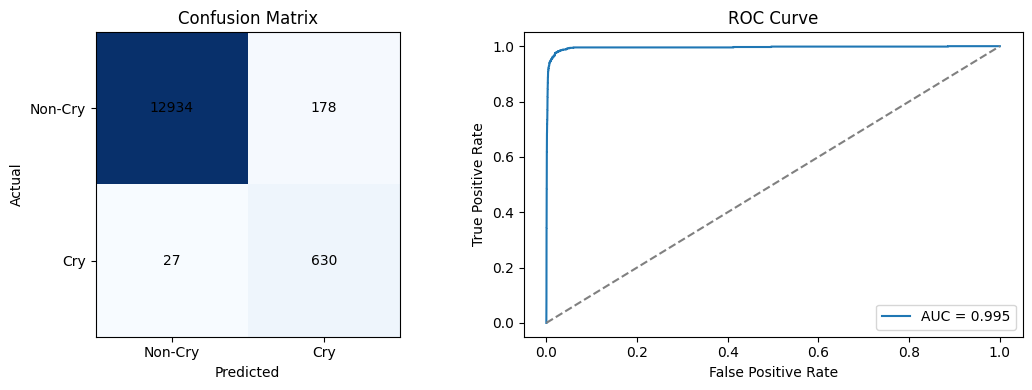

In [ ]:

from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve
)
import matplotlib.pyplot as plt

test_probs = cry_classifier.predict(X_test).ravel()
test_preds = (test_probs >= 0.5).astype(int)

print(classification_report(y_test, test_preds, target_names=["Non-Cry", "Cry"]))
print("ROC-AUC:", round(roc_auc_score(y_test, test_probs), 4))

cm = confusion_matrix(y_test, test_preds)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].imshow(cm, cmap="Blues")
axes[0].set_title("Confusion Matrix")
axes[0].set_xticks([0, 1]); axes[0].set_xticklabels(["Non-Cry", "Cry"])
axes[0].set_yticks([0, 1]); axes[0].set_yticklabels(["Non-Cry", "Cry"])
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, cm[i, j], ha="center", va="center")

fpr, tpr, _ = roc_curve(y_test, test_probs)
axes[1].plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, test_probs):.3f}")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[1].set_title("ROC Curve")
axes[1].set_xlabel("False Positive Rate"); axes[1].set_ylabel("True Positive Rate")
axes[1].legend()

plt.tight_layout()
plt.show()


## Step 10 — Save the model for later use

In [ ]:

SAVE_PATH = "/content/cry_detector_classifier.keras"
cry_classifier.save(SAVE_PATH)
print("Saved classifier head to", SAVE_PATH)
print("(YAMNet itself is loaded fresh from TF-Hub each time — it is not retrained, "
      "so only the small classifier head needs to be saved.)")


Saved classifier head to /content/cry_detector_classifier.keras
(YAMNet itself is loaded fresh from TF-Hub each time — it is not retrained, so only the small classifier head needs to be saved.)


## Step 11 — Run inference on a brand-new audio file

This is the full end-to-end pipeline for a single new recording: load audio →
YAMNet embedding → trained classifier → `Cry` / `Non-Cry` label.

In [ ]:

def predict_cry(audio_path, model=cry_classifier, threshold=0.5):
    embedding = extract_yamnet_embedding(audio_path)
    if embedding is None:
        return None
    prob_cry = float(model.predict(embedding[np.newaxis, :], verbose=0)[0, 0])
    label = "Cry" if prob_cry >= threshold else "Non-Cry"
    return {"audio_path": audio_path, "label": label, "cry_probability": round(prob_cry, 4)}

# Example — replace with the path to any .wav/.mp3 file you want to test:
# print(predict_cry("/content/some_new_recording.wav"))
